In [ ]:
import random

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import set_random_seed


def build_model(vocab_size: int, max_len: int, num_classes: int) -> Sequential:
    model = Sequential(
        [
            Embedding(input_dim=vocab_size, output_dim=64),
            LSTM(64, dropout=0.2, recurrent_dropout=0.2),
            Dense(64, activation="relu"),
            Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
set_random_seed(SEED)

# Load dataset
df = pd.read_csv("dataset.csv")

# Feature columns and label column
feature_columns = ["MRI", "Microscopy", "Immunohistochemistry", "Localization"]
label_column = "Diagnosis"

# Feature matrix (n_records, 4) of strings
X_vector = df[feature_columns].fillna("").astype(str).to_numpy()

# Row-wise labels (for training) and unique labels (for reference)
y_labels = df[label_column].fillna("").astype(str)
y_unique = y_labels.drop_duplicates().tolist()

# Convert each feature row into one sequence string for tokenizer/RNN input
X_text = (
    df[feature_columns]
    .fillna("")
    .astype(str)
    .apply(lambda row: " [SEP] ".join(row.values.tolist()), axis=1)
    .to_numpy()
)

# Encode label strings to class indices
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_

# Adaptive number of folds based on rarest class count
min_class_count = y_labels.value_counts().min()
if min_class_count < 2:
    raise ValueError(
        "At least one diagnosis class has fewer than 2 samples, cannot run K-fold."
    )
n_splits = min(5, min_class_count)

# RNN/text settings
MAX_WORDS = 10000
MAX_LEN = 120
EPOCHS = 8
BATCH_SIZE = 16

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

all_true = []
all_pred = []
fold_accuracies = []

print("Feature vector shape:", X_vector.shape)
print("Unique label count:", len(y_unique))
print("Class count for training:", len(class_names))
print("Using StratifiedKFold with", n_splits, "folds\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X_text, y_encoded), start=1):
    X_train_text, X_test_text = X_text[train_idx], X_text[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # Fit tokenizer on train fold only
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train_text)

    X_train_seq = tokenizer.texts_to_sequences(X_train_text)
    X_test_seq = tokenizer.texts_to_sequences(X_test_text)

    X_train_pad = pad_sequences(
        X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post"
    )
    X_test_pad = pad_sequences(
        X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post"
    )

    vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
    model = build_model(vocab_size=vocab_size, max_len=MAX_LEN, num_classes=len(class_names))

    # validation_split gives validation metrics inside each train fold
    model.fit(
        X_train_pad,
        y_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    y_pred_probs = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    fold_acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(fold_acc)
    print(f"Fold {fold}/{n_splits} accuracy: {fold_acc:.4f}")

    all_true.extend(y_test.tolist())
    all_pred.extend(y_pred.tolist())

print("\nMean CV accuracy:", f"{np.mean(fold_accuracies):.4f}")

# Confusion matrix across all test folds
cm = confusion_matrix(all_true, all_pred, labels=np.arange(len(class_names)))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv("confusion_matrix.csv")

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm_df)
print("\nSaved full confusion matrix to confusion_matrix.csv")






In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder


def normalize_text(value: object) -> str:
    if pd.isna(value):
        return "<MISSING>"
    text = str(value).strip()
    if text == "" or text == "0":
        return "<MISSING>"
    return text


def plot_confusion_matrix(cm: np.ndarray, class_labels: np.ndarray) -> None:
    fig_size = max(8, len(class_labels) * 0.8)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    image = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(image, ax=ax)

    ax.set(
        xticks=np.arange(len(class_labels)),
        yticks=np.arange(len(class_labels)),
        xticklabels=class_labels,
        yticklabels=class_labels,
        ylabel="True label",
        xlabel="Predicted label",
        title="Confusion Matrix (TF-IDF + Logistic Regression)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    threshold = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
            )

    fig.tight_layout()
    plt.show()


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Load dataset
df = pd.read_csv("dataset.csv")

# Feature columns and label column
feature_columns = ["MRI", "Microscopy", "Immunohistochemistry", "Localization"]
label_column = "Diagnosis"

# Feature matrix (n_records, 4) of strings
X_df = df[feature_columns].apply(lambda col: col.map(normalize_text))
X_vector = X_df.to_numpy()

# Row-wise labels (for training) and unique labels (for reference)
y_labels = df[label_column].fillna("").astype(str)
y_unique = y_labels.drop_duplicates().tolist()

# Encode label strings to class indices
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_

# Adaptive number of folds based on rarest class count
min_class_count = y_labels.value_counts().min()
if min_class_count < 2:
    raise ValueError(
        "At least one diagnosis class has fewer than 2 samples, cannot run K-fold."
    )
n_splits = min(5, min_class_count)

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

all_true = []
all_pred = []
fold_accuracies = []

print("Feature vector shape:", X_vector.shape)
print("Unique label count:", len(y_unique))
print("Class count for training:", len(class_names))
print("Using StratifiedKFold with", n_splits, "folds\n")

for fold, (train_idx, test_idx) in enumerate(
    skf.split(np.zeros(len(y_encoded)), y_encoded), start=1
):
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # Presence flags add explicit missingness information.
    train_presence = np.column_stack(
        [(X_df[col].to_numpy()[train_idx] != "<MISSING>") for col in feature_columns]
    ).astype(np.float32)
    test_presence = np.column_stack(
        [(X_df[col].to_numpy()[test_idx] != "<MISSING>") for col in feature_columns]
    ).astype(np.float32)

    # Build fold-specific TF-IDF encoders to avoid leakage.
    train_feature_matrices = []
    test_feature_matrices = []
    for col in feature_columns:
        vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=5000,
            lowercase=True,
        )
        train_text = X_df[col].to_numpy()[train_idx]
        test_text = X_df[col].to_numpy()[test_idx]

        X_train_col = vectorizer.fit_transform(train_text)
        X_test_col = vectorizer.transform(test_text)

        train_feature_matrices.append(X_train_col)
        test_feature_matrices.append(X_test_col)

    X_train_all = hstack(
        train_feature_matrices + [csr_matrix(train_presence)], format="csr"
    )
    X_test_all = hstack(test_feature_matrices + [csr_matrix(test_presence)], format="csr")

    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED,
        solver="lbfgs",
    )
    clf.fit(X_train_all, y_train)
    y_pred = clf.predict(X_test_all)

    fold_acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(fold_acc)
    print(f"Fold {fold}/{n_splits} accuracy: {fold_acc:.4f}")

    all_true.extend(y_test.tolist())
    all_pred.extend(y_pred.tolist())

print("\nMean CV accuracy:", f"{np.mean(fold_accuracies):.4f}")

# Confusion matrix across all test folds
cm = confusion_matrix(all_true, all_pred, labels=np.arange(len(class_names)))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm_df)
plot_confusion_matrix(cm=cm, class_labels=class_names)






In [ ]:
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder


def normalize_text(value: object) -> str:
    if pd.isna(value):
        return "<MISSING>"
    text = str(value).strip()
    if text == "" or text == "0":
        return "<MISSING>"
    return text


def plot_confusion_matrix(cm: np.ndarray, class_labels: np.ndarray) -> None:
    fig_size = max(8, len(class_labels) * 0.8)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    image = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(image, ax=ax)

    ax.set(
        xticks=np.arange(len(class_labels)),
        yticks=np.arange(len(class_labels)),
        xticklabels=class_labels,
        yticklabels=class_labels,
        ylabel="True label",
        xlabel="Predicted label",
        title="Confusion Matrix (TF-IDF + MLP Neural Network)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    threshold = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
            )

    fig.tight_layout()
    plt.show()


def plot_learning_curves(
    train_losses: list[list[float]], val_losses: list[list[float]]
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left plot: training loss
    for fold_idx, loss_values in enumerate(train_losses, start=1):
        epochs = np.arange(1, len(loss_values) + 1)
        axes[0].plot(epochs, loss_values, alpha=0.35, label=f"Fold {fold_idx}")

    max_loss_len = max(len(values) for values in train_losses)
    padded_losses = np.full((len(train_losses), max_loss_len), np.nan)
    for i, values in enumerate(train_losses):
        padded_losses[i, : len(values)] = values
    mean_losses = np.nanmean(padded_losses, axis=0)
    axes[0].plot(
        np.arange(1, max_loss_len + 1),
        mean_losses,
        color="black",
        linewidth=2.5,
        label="Mean",
    )
    axes[0].set_title("Training Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.2)
    axes[0].legend(loc="best")

    # Right plot: validation loss
    for fold_idx, loss_values in enumerate(val_losses, start=1):
        epochs = np.arange(1, len(loss_values) + 1)
        axes[1].plot(epochs, loss_values, alpha=0.35, label=f"Fold {fold_idx}")

    max_val_len = max(len(values) for values in val_losses)
    padded_vals = np.full((len(val_losses), max_val_len), np.nan)
    for i, values in enumerate(val_losses):
        padded_vals[i, : len(values)] = values
    mean_vals = np.nanmean(padded_vals, axis=0)
    axes[1].plot(
        np.arange(1, max_val_len + 1),
        mean_vals,
        color="black",
        linewidth=2.5,
        label="Mean",
    )
    axes[1].set_title("Validation Loss Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(alpha=0.2)
    axes[1].legend(loc="best")

    fig.suptitle("MLP Learning Curves Across K-Folds", fontsize=13)
    fig.tight_layout()
    plt.show()


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Load dataset
df = pd.read_csv("dataset.csv")

# Feature columns and label column
feature_columns = ["MRI", "Microscopy", "Immunohistochemistry", "Localization"]
label_column = "Diagnosis"

# Feature matrix (n_records, 4) of strings
X_df = df[feature_columns].apply(lambda col: col.map(normalize_text))
X_vector = X_df.to_numpy()

# Row-wise labels (for training) and unique labels (for reference)
y_labels = df[label_column].fillna("").astype(str)
y_unique = y_labels.drop_duplicates().tolist()

# Encode label strings to class indices
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_

# Adaptive number of folds based on rarest class count
min_class_count = y_labels.value_counts().min()
if min_class_count < 2:
    raise ValueError(
        "At least one diagnosis class has fewer than 2 samples, cannot run K-fold."
    )
n_splits = min(5, min_class_count)

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

all_true = []
all_pred = []
fold_accuracies = []
fold_train_losses = []
fold_val_losses = []

MAX_EPOCHS = 200
PATIENCE = 15

print("Feature vector shape:", X_vector.shape)
print("Unique label count:", len(y_unique))
print("Class count for training:", len(class_names))
print("Using StratifiedKFold with", n_splits, "folds\n")

for fold, (train_idx, test_idx) in enumerate(
    skf.split(np.zeros(len(y_encoded)), y_encoded), start=1
):
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # Presence flags add explicit missingness information.
    train_presence = np.column_stack(
        [(X_df[col].to_numpy()[train_idx] != "<MISSING>") for col in feature_columns]
    ).astype(np.float32)
    test_presence = np.column_stack(
        [(X_df[col].to_numpy()[test_idx] != "<MISSING>") for col in feature_columns]
    ).astype(np.float32)

    # Build fold-specific TF-IDF encoders to avoid leakage.
    train_feature_matrices = []
    test_feature_matrices = []
    for col in feature_columns:
        vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=5000,
            lowercase=True,
        )
        train_text = X_df[col].to_numpy()[train_idx]
        test_text = X_df[col].to_numpy()[test_idx]

        X_train_col = vectorizer.fit_transform(train_text)
        X_test_col = vectorizer.transform(test_text)

        train_feature_matrices.append(X_train_col)
        test_feature_matrices.append(X_test_col)

    X_train_all = hstack(
        train_feature_matrices + [csr_matrix(train_presence)], format="csr"
    )
    X_test_all = hstack(test_feature_matrices + [csr_matrix(test_presence)], format="csr")

    # Build an explicit train/validation split so we can track validation loss.
    try:
        X_subtrain, X_val, y_subtrain, y_val = train_test_split(
            X_train_all,
            y_train,
            test_size=0.1,
            stratify=y_train,
            random_state=SEED + fold,
        )
    except ValueError:
        X_subtrain, X_val, y_subtrain, y_val = train_test_split(
            X_train_all,
            y_train,
            test_size=0.1,
            random_state=SEED + fold,
        )

    clf = MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=1,
        warm_start=True,
        early_stopping=False,
        random_state=SEED,
    )
    classes = np.arange(len(class_names))
    fold_train_loss = []
    fold_val_loss = []
    best_val_loss = float("inf")
    best_model = None
    epochs_without_improve = 0

    for epoch in range(MAX_EPOCHS):
        if epoch == 0:
            clf.partial_fit(X_subtrain, y_subtrain, classes=classes)
        else:
            clf.partial_fit(X_subtrain, y_subtrain)

        fold_train_loss.append(clf.loss_)
        val_probs = clf.predict_proba(X_val)
        current_val_loss = log_loss(y_val, val_probs, labels=classes)
        fold_val_loss.append(current_val_loss)

        if current_val_loss < best_val_loss - 1e-6:
            best_val_loss = current_val_loss
            best_model = deepcopy(clf)
            epochs_without_improve = 0
        else:
            epochs_without_improve += 1

        if epochs_without_improve >= PATIENCE:
            break

    clf = best_model if best_model is not None else clf
    y_pred = clf.predict(X_test_all)
    fold_train_losses.append(fold_train_loss)
    fold_val_losses.append(fold_val_loss)

    fold_acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(fold_acc)
    print(f"Fold {fold}/{n_splits} accuracy: {fold_acc:.4f}")

    all_true.extend(y_test.tolist())
    all_pred.extend(y_pred.tolist())

print("\nMean CV accuracy:", f"{np.mean(fold_accuracies):.4f}")

# Confusion matrix across all test folds
cm = confusion_matrix(all_true, all_pred, labels=np.arange(len(class_names)))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm_df)
plot_learning_curves(train_losses=fold_train_losses, val_losses=fold_val_losses)
plot_confusion_matrix(cm=cm, class_labels=class_names)






FileNotFoundError: [Errno 2] No such file or directory: 'dataset.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

In [ ]:
def normalize_text(value: object) -> str:
    if pd.isna(value):
        return "<MISSING>"
    text = str(value).strip()
    if text == "" or text == "0":
        return "<MISSING>"
    return text

In [ ]:
def plot_confusion_matrix(cm: np.ndarray, class_labels: np.ndarray) -> None:
    fig_size = max(8, len(class_labels) * 0.8)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    image = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(image, ax=ax)

    ax.set(
        xticks=np.arange(len(class_labels)),
        yticks=np.arange(len(class_labels)),
        xticklabels=class_labels,
        yticklabels=class_labels,
        ylabel="True label",
        xlabel="Predicted label",
        title="Confusion Matrix (TF-IDF + MLP Neural Network)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    threshold = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
            )

    fig.tight_layout()
    plt.show()

In [ ]:
def plot_learning_curves(
    train_losses: list[list[float]], val_losses: list[list[float]]
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left plot: training loss
    for fold_idx, loss_values in enumerate(train_losses, start=1):
        epochs = np.arange(1, len(loss_values) + 1)
        axes[0].plot(epochs, loss_values, alpha=0.35, label=f"Fold {fold_idx}")

    max_loss_len = max(len(values) for values in train_losses)
    padded_losses = np.full((len(train_losses), max_loss_len), np.nan)
    for i, values in enumerate(train_losses):
        padded_losses[i, : len(values)] = values
    mean_losses = np.nanmean(padded_losses, axis=0)
    axes[0].plot(
        np.arange(1, max_loss_len + 1),
        mean_losses,
        color="black",
        linewidth=2.5,
        label="Mean",
    )
    axes[0].set_title("Training Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.2)
    axes[0].legend(loc="best")

    # Right plot: validation loss
    for fold_idx, loss_values in enumerate(val_losses, start=1):
        epochs = np.arange(1, len(loss_values) + 1)
        axes[1].plot(epochs, loss_values, alpha=0.35, label=f"Fold {fold_idx}")

    max_val_len = max(len(values) for values in val_losses)
    padded_vals = np.full((len(val_losses), max_val_len), np.nan)
    for i, values in enumerate(val_losses):
        padded_vals[i, : len(values)] = values
    mean_vals = np.nanmean(padded_vals, axis=0)
    axes[1].plot(
        np.arange(1, max_val_len + 1),
        mean_vals,
        color="black",
        linewidth=2.5,
        label="Mean",
    )
    axes[1].set_title("Validation Loss Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(alpha=0.2)
    axes[1].legend(loc="best")

    fig.suptitle("MLP Learning Curves Across K-Folds", fontsize=13)
    fig.tight_layout()
    plt.show()

In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset.csv")

# Feature columns and label column
feature_columns = ["MRI", "Microscopy", "Immunohistochemistry", "Localization"]
label_column = "Diagnosis"

# Feature matrix (n_records, 4) of strings
X_df = df[feature_columns].apply(lambda col: col.map(normalize_text))
X_vector = X_df.to_numpy()

# Row-wise labels (for training) and unique labels (for reference)
y_labels = df[label_column].fillna("").astype(str)
y_unique = y_labels.drop_duplicates().tolist()

# Encode label strings to class indices
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_

In [ ]:
# Adaptive number of folds based on rarest class count
min_class_count = y_labels.value_counts().min()
if min_class_count < 2:
    raise ValueError(
        "At least one diagnosis class has fewer than 2 samples, cannot run K-fold."
    )
n_splits = min(5, min_class_count)

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

In [ ]:
all_true = []
all_pred = []
fold_accuracies = []
fold_train_losses = []
fold_val_losses = []

MAX_EPOCHS = 200
PATIENCE = 15

print("Feature vector shape:", X_vector.shape)
print("Unique label count:", len(y_unique))
print("Class count for training:", len(class_names))
print("Using StratifiedKFold with", n_splits, "folds\n")

Feature vector shape: (298, 4)
Unique label count: 12
Class count for training: 12
Using StratifiedKFold with 5 folds



In [ ]:
for fold, (train_idx, test_idx) in enumerate(
    skf.split(np.zeros(len(y_encoded)), y_encoded), start=1
):
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # Presence flags add explicit missingness information.
    train_presence = np.column_stack(
        [(X_df[col].to_numpy()[train_idx] != "<MISSING>") for col in feature_columns]
    ).astype(np.float32)
    test_presence = np.column_stack(
        [(X_df[col].to_numpy()[test_idx] != "<MISSING>") for col in feature_columns]
    ).astype(np.float32)

    # Build fold-specific TF-IDF encoders to avoid leakage.
    train_feature_matrices = []
    test_feature_matrices = []
    for col in feature_columns:
        vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=5000,
            lowercase=True,
        )
        train_text = X_df[col].to_numpy()[train_idx]
        test_text = X_df[col].to_numpy()[test_idx]

        X_train_col = vectorizer.fit_transform(train_text)
        X_test_col = vectorizer.transform(test_text)

        train_feature_matrices.append(X_train_col)
        test_feature_matrices.append(X_test_col)

    X_train_all = hstack(
        train_feature_matrices + [csr_matrix(train_presence)], format="csr"
    )
    X_test_all = hstack(test_feature_matrices + [csr_matrix(test_presence)], format="csr")

    # Build an explicit train/validation split so we can track validation loss.
    try:
        X_subtrain, X_val, y_subtrain, y_val = train_test_split(
            X_train_all,
            y_train,
            test_size=0.1,
            stratify=y_train,
            random_state=SEED + fold,
        )
    except ValueError:
        X_subtrain, X_val, y_subtrain, y_val = train_test_split(
            X_train_all,
            y_train,
            test_size=0.1,
            random_state=SEED + fold,
        )

    clf = MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=1,
        warm_start=True,
        early_stopping=False,
        random_state=SEED,
    )
    classes = np.arange(len(class_names))
    fold_train_loss = []
    fold_val_loss = []
    best_val_loss = float("inf")
    best_model = None
    epochs_without_improve = 0

    for epoch in range(MAX_EPOCHS):
        if epoch == 0:
            clf.partial_fit(X_subtrain, y_subtrain, classes=classes)
        else:
            clf.partial_fit(X_subtrain, y_subtrain)

        fold_train_loss.append(clf.loss_)
        val_probs = clf.predict_proba(X_val)
        current_val_loss = log_loss(y_val, val_probs, labels=classes)
        fold_val_loss.append(current_val_loss)

        if current_val_loss < best_val_loss - 1e-6:
            best_val_loss = current_val_loss
            best_model = deepcopy(clf)
            epochs_without_improve = 0
        else:
            epochs_without_improve += 1

        if epochs_without_improve >= PATIENCE:
            break

    clf = best_model if best_model is not None else clf
    y_pred = clf.predict(X_test_all)
    fold_train_losses.append(fold_train_loss)
    fold_val_losses.append(fold_val_loss)

    fold_acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(fold_acc)
    print(f"Fold {fold}/{n_splits} accuracy: {fold_acc:.4f}")

    all_true.extend(y_test.tolist())
    all_pred.extend(y_pred.tolist())

print("\nMean CV accuracy:", f"{np.mean(fold_accuracies):.4f}")

Fold 1/5 accuracy: 0.8667
Fold 2/5 accuracy: 0.9500
Fold 3/5 accuracy: 0.9333
Fold 4/5 accuracy: 0.8136
Fold 5/5 accuracy: 0.9153

Mean CV accuracy: 0.8958



Confusion Matrix (rows=true, cols=pred):
                                                    Atypical ganglioglioma WHO grade II   \
Atypical ganglioglioma WHO grade II                                                    9   
Dysembryoplastic neuroepithelial tumor WHO Grade I                                     0   
Focal Cortical Dysplasia Type IIb                                                      0   
Focal Cortical Dysplasia Type Ib                                                       0   
Focal cortical dysplasia Type IIId                                                     0   
Ganglioglioma WHO grade I                                                              0   
Hippocampal sclerosis Type I                                                           0   
Mild Malformation of Cortical Development Type II                                      0   
Mild malformation of cortical development                                              0   
No Hippocampal sclerosis              

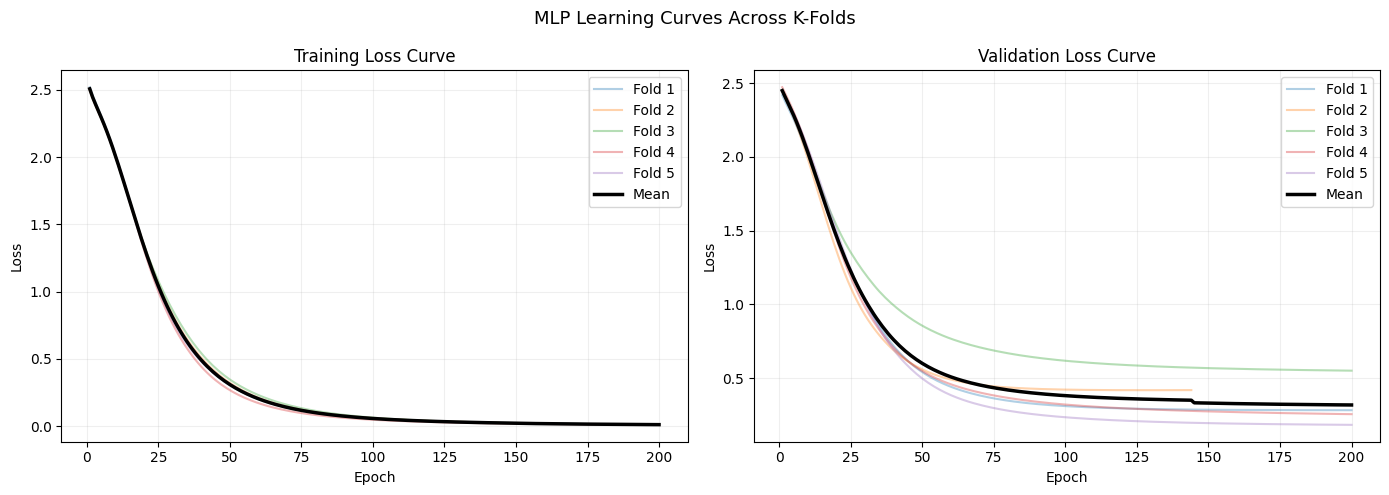

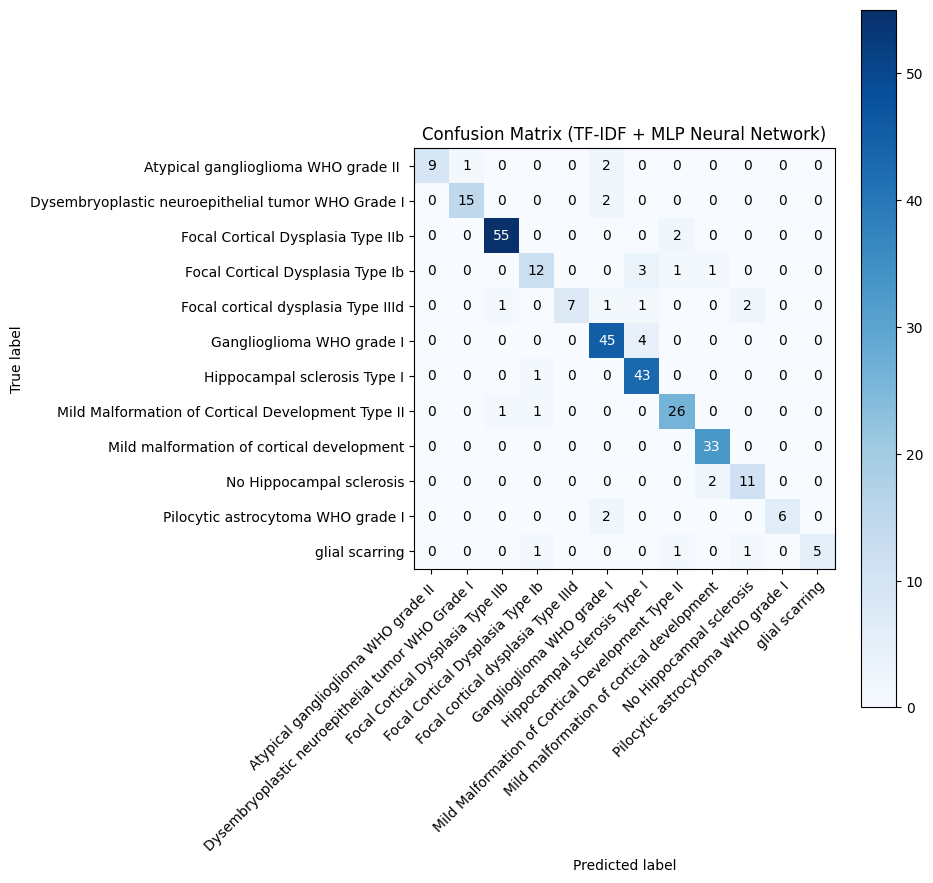

In [ ]:
# Confusion matrix across all test folds
cm = confusion_matrix(all_true, all_pred, labels=np.arange(len(class_names)))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm_df)
plot_learning_curves(train_losses=fold_train_losses, val_losses=fold_val_losses)
plot_confusion_matrix(cm=cm, class_labels=class_names)